# 01 · Data preparation and TF-IDF baseline

Amazon Echo Dot 2 reviews, mapped from star ratings to three classes:
4-5 stars = satisfied, 3 = neutral, 1-2 = not satisfied.

This notebook cleans the data, makes the train/test split every model uses, and trains the TF-IDF + logistic regression baseline. Runs on any laptop CPU in about a minute.

In [1]:
from pathlib import Path
# Works whether the notebook runs from the Notebooks folder (VS Code default) or the project root
ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
DATA, OUTPUT = ROOT / 'Data', ROOT / 'Output'
OUTPUT.mkdir(exist_ok=True)

import json, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

LABELS = ['not satisfied', 'neutral', 'satisfied']
SEED = 42

## Load and label

In [2]:
raw = pd.read_csv(DATA / 'Amazon Echo Dot 2 Reviews.csv')
print(raw.shape)
raw['stars'] = raw['Ratting'].str.extract(r'^(\d)').astype(int)   # column name is misspelled in the source
raw['label'] = raw['stars'].map({5: 'satisfied', 4: 'satisfied', 3: 'neutral', 2: 'not satisfied', 1: 'not satisfied'})
raw['label'].value_counts(normalize=True).round(3)

(53048, 12)


label
satisfied        0.809
not satisfied    0.113
neutral          0.078
Name: proportion, dtype: float64

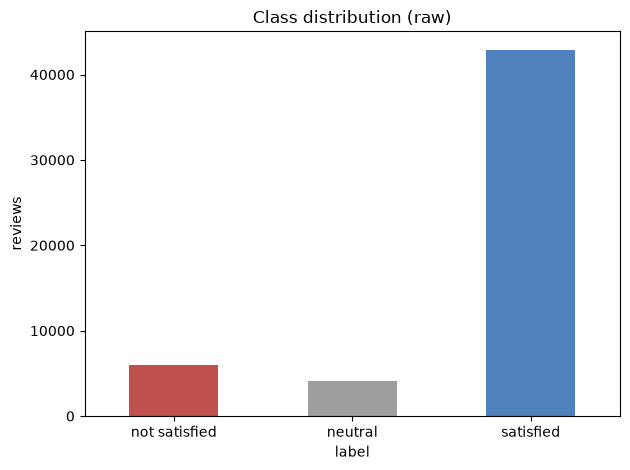

In [3]:
ax = raw['label'].value_counts().reindex(LABELS).plot.bar(rot=0, color=['#c0504d', '#9e9e9e', '#4f81bd'])
ax.set_title('Class distribution (raw)'); ax.set_ylabel('reviews')
plt.tight_layout(); plt.savefig(OUTPUT / 'class_distribution.png', dpi=120); plt.show()

## Clean and split

- Drop empty reviews.
- Drop duplicate texts so the same review can't be in both train and test (mostly short ones like "Love it").
- Keep the review **title** people wrote, but blank Amazon's automatic titles ("Five Stars", "One Star", ...). Those are generated from the rating itself and would leak the label. About 30% of reviews have one.

In [4]:
AUTO_TITLE = r'^\s*(one|two|three|four|five)\s+stars?\s*$'
df = (raw.dropna(subset=['Review Text'])
          .rename(columns={'Uniq Id': 'id', 'Review Date': 'date', 'Review Text': 'text', 'Title': 'title'})
          .drop_duplicates('text')[['id', 'date', 'title', 'text', 'stars', 'label']])
df['title'] = df['title'].fillna('').str.strip()
df.loc[df['title'].str.match(AUTO_TITLE, case=False), 'title'] = ''
print(len(df), 'reviews after cleaning |', f"{(df.title == '').mean():.0%} have no usable title")
print(df.text.str.split().str.len().describe().round(1))

train, test = train_test_split(df, test_size=0.2, stratify=df.label, random_state=SEED)
train.to_csv(DATA / 'train.csv', index=False); test.to_csv(DATA / 'test.csv', index=False)
print(len(train), len(test))

44200 reviews after cleaning | 29% have no usable title
count    44200.0
mean        40.0
std         68.8
min          1.0
25%          9.0
50%         20.0
75%         45.0
max       3566.0
Name: text, dtype: float64
35360 8840


## Baseline: TF-IDF + logistic regression

`class_weight='balanced'` matters: without it the model almost never predicts neutral. Judge by macro-F1, since always predicting "satisfied" already scores about 80% accuracy.

In [5]:
baseline = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=2000, class_weight='balanced'))
baseline.fit(train.text, train.label)
pred = baseline.predict(test.text)
print(classification_report(test.label, pred, labels=LABELS, digits=3))
macro_f1 = f1_score(test.label, pred, average='macro')
print('macro-F1:', round(macro_f1, 3))

               precision    recall  f1-score   support

not satisfied      0.674     0.720     0.696      1081
      neutral      0.340     0.567     0.425       755
    satisfied      0.969     0.889     0.927      7004

     accuracy                          0.841      8840
    macro avg      0.661     0.725     0.683      8840
 weighted avg      0.879     0.841     0.856      8840

macro-F1: 0.683


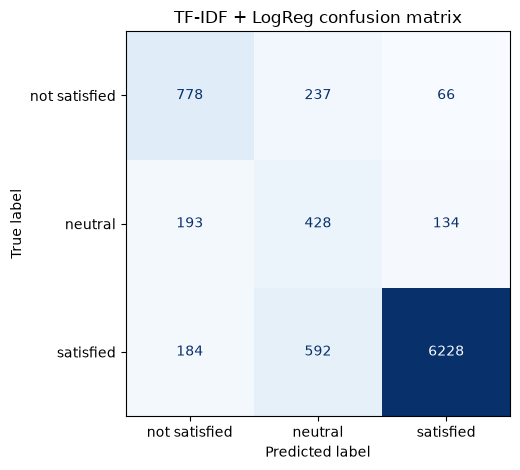

In [6]:
ConfusionMatrixDisplay.from_predictions(test.label, pred, labels=LABELS, cmap='Blues', colorbar=False)
plt.title('TF-IDF + LogReg confusion matrix'); plt.tight_layout()
plt.savefig(OUTPUT / 'confusion_matrix_baseline.png', dpi=120); plt.show()

In [7]:
joblib.dump(baseline, OUTPUT / 'tfidf_logreg_baseline.joblib')
report = classification_report(test.label, pred, labels=LABELS, output_dict=True)
json.dump({'model': 'tfidf_logreg_balanced', 'macro_f1': macro_f1,
           'recall': {l: report[l]['recall'] for l in LABELS}}, open(OUTPUT / 'results_baseline.json', 'w'), indent=2)
baseline.predict(["Love it, works great", "It's ok, the sound is meh", "Stopped working after a week"])

array(['satisfied', 'neutral', 'not satisfied'], dtype=object)